In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score

df = pd.read_csv("C:/Users/claire_lee/source/datasets/Social_Network_Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [5]:
x = df.iloc[:,[2,3]].values.astype("float32")
y = df.iloc[:,4].values
x.shape, y.shape

((400, 2), (400,))

In [6]:
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, random_state=0)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((320, 2), (80, 2), (320,), (80,))

In [7]:
sc= StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [8]:
RandomForestClassifier?

Init signature:
RandomForestClassifier(
    n_estimators=100,
    *,
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features='sqrt',
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    bootstrap=True,
    oob_score=False,
    n_jobs=None,
    random_state=None,
    verbose=0,
    warm_start=False,
    class_weight=None,
    ccp_alpha=0.0,
    max_samples=None,
    monotonic_cst=None,
)
Docstring:     
A random forest classifier.

A random forest is a meta estimator that fits a number of decision tree
classifiers on various sub-samples of the dataset and uses averaging to
improve the predictive accuracy and control over-fitting.
Trees in the forest use the best split strategy, i.e. equivalent to passing
`splitter="best"` to the underlying :class:`~sklearn.tree.DecisionTreeRegressor`.
The sub-sample size is controlled with the `max_samples` parameter if
`bootstrap=True` (default), otherwise the 

In [9]:
rf=RandomForestClassifier(n_estimators=10,random_state=0)
rf.fit(x_train,y_train)

RandomForestClassifier(n_estimators=10, random_state=0)

In [10]:
from sklearn.ensemble import GradientBoostingClassifier
gb=GradientBoostingClassifier(learning_rate=0.1, n_estimators=500, max_depth=5)
gb.fit(x_train, y_train)

GradientBoostingClassifier(max_depth=5, n_estimators=500)

In [11]:
y_pred = gb.predict(x_test)
accuracy_score(y_test, y_pred)

0.925

In [12]:
from matplotlib.colors import ListedColormap
cmap_bold = ListedColormap(['#FF0000','#00FF00'])
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])

In [13]:
np.meshgrid([1,2,3,4],[5,6,7,8])

[array([[1, 2, 3, 4],
        [1, 2, 3, 4],
        [1, 2, 3, 4],
        [1, 2, 3, 4]]),
 array([[5, 5, 5, 5],
        [6, 6, 6, 6],
        [7, 7, 7, 7],
        [8, 8, 8, 8]])]

In [14]:
x1_min,x1_max = x_test[:,0].min()-1, x_test[:,0].max()+1
x2_min,x2_max = x_test[:,1].min()-1, x_test[:,1].max()+1

x1, x2 = np.meshgrid(np.arange(x1_min, x1_max, 0.1),np.arange(x2_min, x2_max, 0.1))

In [15]:
xx = np.column_stack([x1.ravel(), x2.ravel()])
xx.shape

(3660, 2)

In [16]:
y_rf= rf.predict(xx)
y_gb = gb.predict(xx)

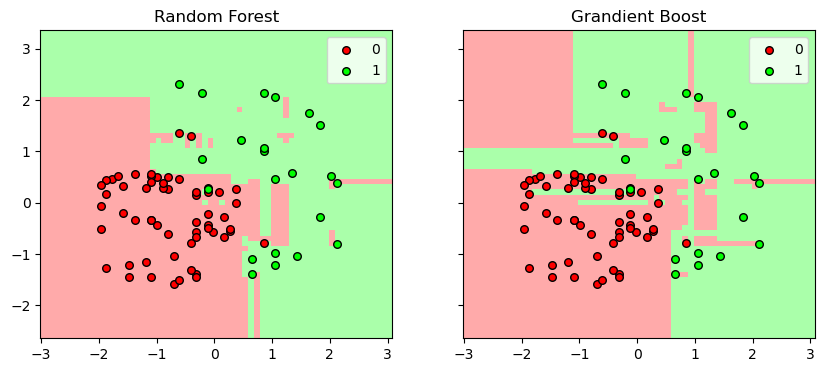

In [37]:
fig,(ax1, ax2) = plt.subplots(1,2,figsize=(10,4), sharey=True)
ax1.pcolormesh(x1, x2, y_rf.reshape(x1.shape),cmap=cmap_light, shading='auto')
for i in range(2):
    ax1.scatter(x_test[y_test == i,0],x_test[y_test == i,1], color=cmap_bold(i), label=i, s=30, edgecolors='k')
ax1.set_title('Random Forest')
ax1.legend()

ax2.pcolormesh(x1, x2, y_gb.reshape(x1.shape),cmap=cmap_light, shading='auto')
for i in range(2):
    ax2.scatter(x_test[y_test == i,0],x_test[y_test == i,1], color=cmap_bold(i), label=i, s=30, edgecolors='k')
ax2.set_title("Grandient Boost")
ax2.legend()

In [39]:
gb.feature_importances_

array([0.49483128, 0.50516872])

In [43]:
feature_imp=pd.Series(gb.feature_importances_,['Age','Estimated Salary'])
feature_imp

Age                 0.494831
Estimated Salary    0.505169
dtype: float64

<Axes: title={'center': 'Freature Importance'}>

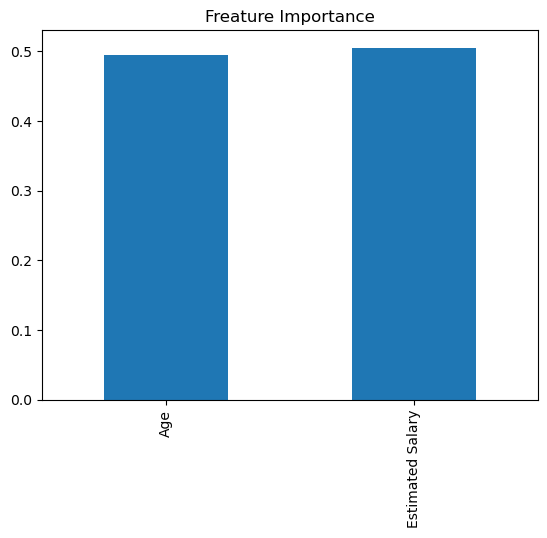

In [45]:
feature_imp.plot(kind='bar', title='Freature Importance')